In [91]:
import numpy as np
import polars as pl
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [92]:
DATA_PATH = "raw/processed_gtfs/baseline_dataset.parquet"
 
df = pl.read_parquet(DATA_PATH)
print(df.shape)
 
TARGET = "travel_time"
CATEGORICAL = ["route_id", "direction_id", "shape_id", "service_id", 'is_raining', 'is_snowing', 'is_fog', "is_weekend",
    "is_federal_holiday",
    "is_school_day",
    "has_major_event",]
NUMERIC = [
    "stop_sequence", "trip_progress",
    "hour", "weekday", "month", "is_peak",
    "scheduled_arrival", "scheduled_departure", "scheduled_segment_time",
    "stop_lat", "stop_lon", "latitude", "longitude", "bearing",
    'temperature_c', 'precipitation_mm', 'snowfall_cm', 'windspeed_kmh', 'weathercode',
    'segment_length',
    'scheduled_segment_speed_mps',
    'upstream_delay_seconds',
    'speed_mps',
    'headway_seconds',
    "ridership",
    "transfers",
    
]

FEATURES = CATEGORICAL + NUMERIC

(56764, 40)


In [93]:
groups = df["trip_id"].to_numpy()
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=groups))
 
train_df = df[train_idx]
test_df = df[test_idx]

 
print(f"train: {train_df.shape} | test: {test_df.shape}")
print(f"train trips: {train_df['trip_id'].n_unique():,} | "
      f"test trips: {test_df['trip_id'].n_unique():,} | "
      f"overlap: {len(set(train_df['trip_id']) & set(test_df['trip_id']))}")

train: (45363, 40) | test: (11401, 40)
train trips: 996 | test trips: 250 | overlap: 0


In [94]:
for c in FEATURES:
    print(c, train_df.schema[c])

route_id String
direction_id Int64
shape_id String
service_id String
is_raining Int8
is_snowing Int8
is_fog Int8
is_weekend Boolean
is_federal_holiday Boolean
is_school_day Boolean
has_major_event Boolean
stop_sequence UInt32
trip_progress Float64
hour Int8
weekday Int8
month Int8
is_peak Int8
scheduled_arrival Int32
scheduled_departure Int32
scheduled_segment_time Int32
stop_lat Float64
stop_lon Float64
latitude Float32
longitude Float32
bearing Float32
temperature_c Float64
precipitation_mm Float64
snowfall_cm Float64
windspeed_kmh Float64
weathercode Int64
segment_length Float64
scheduled_segment_speed_mps Float64
upstream_delay_seconds Int64
speed_mps Float64
headway_seconds Int64
ridership Int64
transfers Int64


In [95]:
import pandas as pd
 
def to_pandas_typed(pl_df: pl.DataFrame) -> pd.DataFrame:

    cols = {}
    for col in FEATURES:
        s = pl_df[col]
        if col in CATEGORICAL:
            cols[col] = pd.Series(s.to_list(), dtype="category")
        else:
            cols[col] = s.to_numpy()
    return pd.DataFrame(cols)
 
X_train = to_pandas_typed(train_df)
X_test = to_pandas_typed(test_df)
y_train = train_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

In [96]:
model = lgb.LGBMRegressor(
    objective="regression",
    metric="mae",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
 
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="mae",
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001548 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3980
[LightGBM] [Info] Number of data points in the train set: 45363, number of used features: 30
[LightGBM] [Info] Start training from score 92.637017
Training until validation scores don't improve for 50 rounds


c:\Users\ishan\anaconda3\envs\DL\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[100]	valid_0's l1: 33.1776
[200]	valid_0's l1: 32.4654
[300]	valid_0's l1: 32.2479
[400]	valid_0's l1: 32.18
[500]	valid_0's l1: 32.1068
[600]	valid_0's l1: 32.0996
Early stopping, best iteration is:
[551]	valid_0's l1: 32.0914


,num_leaves,63
,learning_rate,0.03
,n_estimators,2000
,objective,'regression'
,min_child_samples,30
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,metric,'mae'
,boosting_type,'gbdt'
,max_depth,-1


In [97]:
preds = model.predict(X_test, num_iteration=model.best_iteration_)
 
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
 
print(f"MAE:  {mae:.1f} sec")
print(f"RMSE: {rmse:.1f} sec")
print(f"R2:   {r2:.4f}")
 
# naive baseline for comparison: predict the scheduled segment time as-is
naive_preds = test_df["scheduled_segment_time"].to_numpy()
naive_mae = mean_absolute_error(y_test, naive_preds)
print(f"\nNaive baseline (scheduled_segment_time only) MAE: {naive_mae:.1f} sec")
print(f"Improvement over naive: {(1 - mae / naive_mae) * 100:.1f}%")

MAE:  32.1 sec
RMSE: 58.2 sec
R2:   0.4775

Naive baseline (scheduled_segment_time only) MAE: 47.4 sec
Improvement over naive: 32.3%


In [98]:
importance = (
    pl.DataFrame({
        "feature": X_train.columns.tolist(),
        "importance": model.feature_importances_,
    })
    .sort("importance", descending=True)
)
print(importance)
 
# %%
# ---------------------------------------------------
# Save
# ---------------------------------------------------
 
model.booster_.save_model("models/lgbm_weather_segments_delay_and_ridership.txt")
print("model saved")

shape: (37, 2)
┌────────────────────────┬────────────┐
│ feature                ┆ importance │
│ ---                    ┆ ---        │
│ str                    ┆ i32        │
╞════════════════════════╪════════════╡
│ segment_length         ┆ 3007       │
│ upstream_delay_seconds ┆ 2664       │
│ scheduled_segment_time ┆ 2496       │
│ speed_mps              ┆ 2332       │
│ headway_seconds        ┆ 2010       │
│ …                      ┆ …          │
│ is_weekend             ┆ 0          │
│ is_federal_holiday     ┆ 0          │
│ is_school_day          ┆ 0          │
│ has_major_event        ┆ 0          │
│ snowfall_cm            ┆ 0          │
└────────────────────────┴────────────┘
model saved


                        Feature  Importance
30               segment_length        3007
32       upstream_delay_seconds        2664
19       scheduled_segment_time        2496
33                    speed_mps        2332
34              headway_seconds        2010
12                trip_progress        1939
24                      bearing        1925
20                     stop_lat        1774
2                      shape_id        1723
21                     stop_lon        1683
22                     latitude        1667
17            scheduled_arrival        1662
23                    longitude        1624
31  scheduled_segment_speed_mps        1575
11                stop_sequence        1380
35                    ridership        1065
36                    transfers         895
28                windspeed_kmh         729
25                temperature_c         722
13                         hour         408
18          scheduled_departure         295
29                  weathercode 

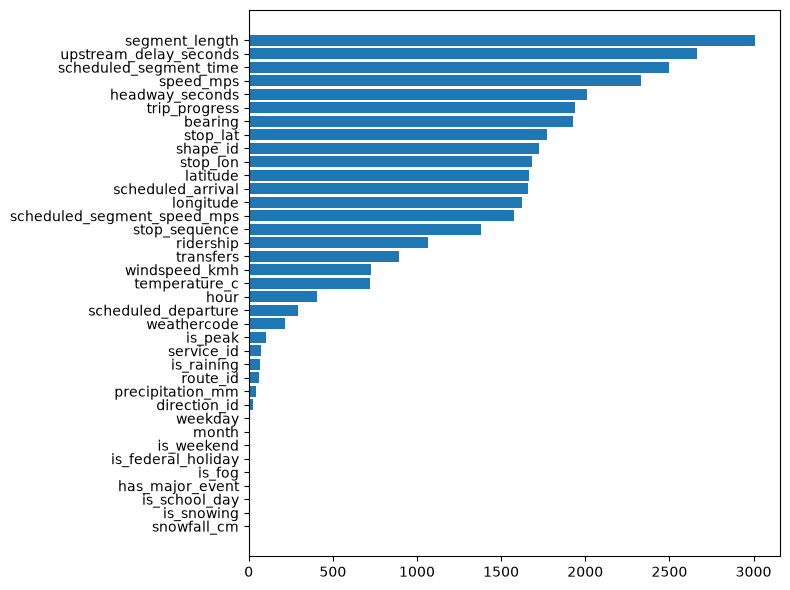

In [99]:
import matplotlib.pyplot as plt
import pandas as pd

fi = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(fi)

plt.figure(figsize=(8,6))
plt.barh(fi["Feature"], fi["Importance"])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()